In [4]:
import pandas as pd

df = pd.read_csv("data.csv", on_bad_lines="skip")

print("Dataset loaded successfully!")

print("\nFirst 5 rows:")
print(df.head())

print("\nColumn Names:")
print(df.columns)

print("\nDataset Shape:")
print(df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

Dataset loaded successfully!

First 5 rows:
      password  strength
0     kzde5577         1
1     kino3434         1
2    visi7k1yr         1
3     megzy123         1
4  lamborghin1         1

Column Names:
Index(['password', 'strength'], dtype='object')

Dataset Shape:
(669640, 2)

Missing Values:
password    1
strength    0
dtype: int64


In [7]:
print("Dataset Information:")
print(df.info())

print("\nStrength Distribution:")
print(df['strength'].value_counts())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 669640 entries, 0 to 669639
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype 
---  ------    --------------   ----- 
 0   password  669639 non-null  object
 1   strength  669640 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 10.2+ MB
None

Strength Distribution:
1    496801
0     89702
2     83137
Name: strength, dtype: int64


In [8]:
# Feature Extraction

import re

def extract_features(password):
    password = str(password)

    length = len(password)

    uppercase = sum(1 for c in password if c.isupper())

    lowercase = sum(1 for c in password if c.islower())

    numbers = sum(1 for c in password if c.isdigit())

    special_chars = sum(1 for c in password if not c.isalnum())

    # Check whether password contains dictionary/common words
    common_words = [
        'password', 'admin', 'welcome', 'hello',
        'qwerty', 'letmein', 'user', 'india',
        'college', 'python', 'login'
    ]

    dictionary_word = 0

    password_lower = password.lower()

    for word in common_words:
        if word in password_lower:
            dictionary_word = 1
            break

    return [
        length,
        uppercase,
        lowercase,
        numbers,
        special_chars,
        dictionary_word
    ]


# Apply feature extraction
features = df['password'].apply(extract_features)

# Create feature DataFrame
X = pd.DataFrame(
    features.tolist(),
    columns=[
        'length',
        'uppercase',
        'lowercase',
        'numbers',
        'special_chars',
        'dictionary_word'
    ]
)

# Target variable
y = df['strength']

print("Extracted Features:")
print(X.head())

print("\nTarget Values:")
print(y.head())

Extracted Features:
   length  uppercase  lowercase  numbers  special_chars  dictionary_word
0       8          0          4        4              0                0
1       8          0          4        4              0                0
2       9          0          7        2              0                0
3       8          0          5        3              0                0
4      11          0         10        1              0                0

Target Values:
0    1
1    1
2    1
3    1
4    1
Name: strength, dtype: int64


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("\nRandom Forest Model trained successfully!")

Training data: (535712, 6)
Testing data: (133928, 6)

Random Forest Model trained successfully!


In [11]:
from sklearn.metrics import accuracy_score,
classification_report, confusion_matrix

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy Percentage:", accuracy * 100, "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

Accuracy: 1.0
Accuracy Percentage: 100.0 %

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     17941
           1       1.00      1.00      1.00     99360
           2       1.00      1.00      1.00     16627

    accuracy                           1.00    133928
   macro avg       1.00      1.00      1.00    133928
weighted avg       1.00      1.00      1.00    133928


Confusion Matrix:
[[17941     0     0]
 [    0 99360     0]
 [    0     0 16627]]


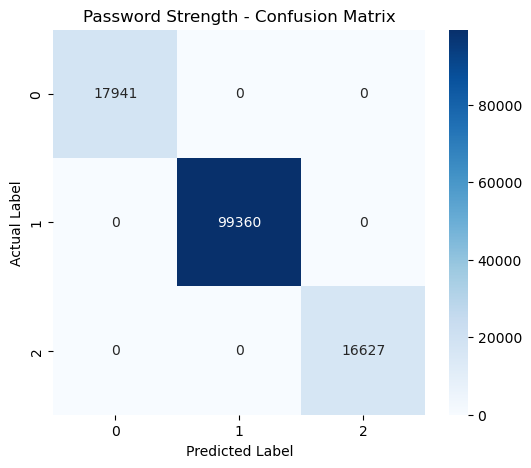

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Password Strength - Confusion Matrix")

plt.show()

In [16]:
password = input("Enter a password: ")

new_features = extract_features(password)

new_data = pd.DataFrame(
    [new_features],
    columns=[
        'length',
        'uppercase',
        'lowercase',
        'numbers',
        'special_chars',
        'dictionary_word'
    ]
)

prediction = model.predict(new_data)[0]

strength_labels = {
    0: "Weak",
    1: "Medium",
    2: "Strong"
}

print("\nPassword:", password)
print("Predicted Password Strength:", strength_labels[prediction])

Enter a password: pass123

Password: pass123
Predicted Password Strength: Weak
